In [1]:
%pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# xarray e netCDF

In [2]:
%pip install netCDF4 h5netcdf

import numpy as np
import pandas as pd
import xarray as xr
from netCDF4 import Dataset

import time
import glob


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# alterar para 2001_2010 para o ano de 2010
ds = xr.open_dataset(r'.\1 - Organized data gauge\BRAZIL\NetCDF\IDW_consolidation_decade_nc\precipitation_idw_2011_2020.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:    (latitude: 392, longitude: 394, date: 3653)
Coordinates:
  * latitude   (latitude) float64 3kB -33.75 -33.65 -33.55 ... 5.15 5.25 5.35
  * longitude  (longitude) float64 3kB -74.05 -73.95 -73.85 ... -34.85 -34.75
  * date       (date) datetime64[ns] 29kB 2011-01-01 2011-01-02 ... 2020-12-31
Data variables:
    pr         (latitude, longitude, date) float64 5GB ...

In [4]:
df = pd.read_excel('./5 - Results/Lista estações.xlsx', sheet_name='Sheet1')
df = df[df['year'] > 2010] # alterar para = 2010 para o ano de 2010
df

FileNotFoundError: [Errno 2] No such file or directory: './5 - Results/Lista estações.xlsx'

In [33]:
def print_lat_long(df):
    start_time = time.time()
    count = 0
    for index, row in df.iterrows():
        lap_time = time.time()
        count += 1
        latitude = row['latitude']
        longitude = row['longitude']
        year = row['year']
        gauge_code = row['gauge_code']
        net = row['net']
        # print(row['latitude'], row['longitude'])

        ds_pr = ds['pr'].sel(latitude=latitude, longitude=longitude, method='nearest')
        df_pr = ds_pr.to_dataframe().reset_index()
        df_pr = df_pr[df_pr['date'].dt.year == year]

        df_pr['year'] = year
        df_pr['gauge_code'] = gauge_code
        df_pr['net']   =   net
        df_pr['gauge_code_lat'] = latitude
        df_pr['gauge_code_lon'] = longitude
        df_pr.rename(columns={'pr': 'rain_mm'}, inplace=True)
        df_pr.to_hdf(f"./5 - Results/Emerson/rain_mm_{gauge_code}_{year}.h5", key="table_data", mode="w", format="table", complevel=0, complib='zlib')
        # print(f"\n{count}/{len(df)}\nProcessed {gauge_code} for year {year} at lat {latitude}, lon {longitude}\n")
        # print(df_pr.head(3))
        print(f"Time taken for {gauge_code} for year {year} at lat {latitude}, lon {longitude}: {time.time() - lap_time:.2f} seconds")
    print(f"\nTotal time taken: {time.time() - start_time:.2f} seconds")

print_lat_long(df)

Time taken for A011 for year 2013 at lat -18.96666666, lon -50.61666666: 0.02 seconds
Time taken for A035 for year 2013 at lat -18.40972222, lon -49.19194444: 0.02 seconds
Time taken for 83526 for year 2013 at lat -18.17027777, lon -47.95805555: 0.02 seconds
Time taken for A034 for year 2013 at lat -18.15777777, lon -47.92638888: 0.02 seconds
Time taken for A016 for year 2013 at lat -17.92388888, lon -51.71777777: 0.02 seconds
Time taken for 83464 for year 2013 at lat -17.9236111, lon -51.71749999: 0.02 seconds
Time taken for A025 for year 2013 at lat -17.78583333, lon -50.98138888: 0.02 seconds
Time taken for 83470 for year 2013 at lat -17.78527777, lon -50.96472222: 0.02 seconds
Time taken for 83522 for year 2013 at lat -17.72444443, lon -48.17194443: 0.02 seconds
Time taken for A026 for year 2013 at lat -17.45472222, lon -52.60111111: 0.02 seconds
Time taken for A033 for year 2013 at lat -17.30416666, lon -48.28416666: 0.02 seconds
Time taken for A037 for year 2013 at lat -16.676944

In [5]:
files = glob.glob(r'./5 - Results/Emerson/*.h5')
df_list = [pd.read_hdf(f) for f in files]
df_final = pd.concat(df_list, ignore_index=True)
df_final

df_final.to_hdf('./5 - Results/Emerson/Base Final/rain_mm_all_years.h5', key='table_data', mode='w', format='table', complevel=0, complib='blosc')
df_final

KeyboardInterrupt: 

In [ ]:
df_list = [pd.read_hdf(f) for f in files]
df_final = pd.concat(df_list, ignore_index=True)
df_final.to_hdf('./5 - Results/Emerson/Base Agregada/rain_mm_all_years.h5', key='table_data', mode='w', format='table', complevel=0, complib='blosc')
df_final

# TESTE TESTE TESTE

In [7]:
latitude = -16.65
longitude = -48.65
year = 2015
date = "2015-07-12"
gauge_code = 'A011'
net = 'INMET'

In [8]:
ds_pr = ds['pr'].sel(latitude=latitude, longitude=longitude, method='nearest')
df_pr = ds_pr.to_dataframe().reset_index()
df_pr = df_pr[df_pr['date'].dt.year == year]
df_pr = df_pr[df_pr['date'] == date]
df_pr['year'] = year
df_pr['gauge_code'] = gauge_code
df_pr['net']   =   net
df_pr['gauge_code_lat'] = latitude
df_pr['gauge_code_lon'] = longitude
df_pr.rename(columns={'pr': 'rain_mm'}, inplace=True)
df_pr

,date,latitude,longitude,rain_mm,year,gauge_code,net,gauge_code_lat,gauge_code_lon
1653,2015-07-12,-16.65,-48.65,170.739222,2015,A011,INMET,-16.65,-48.65


In [18]:
df_pr.to_hdf(f"./5 - Results/Emerson/rain_mm_{gauge_code}_{year}.h5", key="table_data", mode="w", format="table", complevel=0, complib='zlib')
df_pr

,date,latitude,longitude,rain_mm,year,gauge_code,net,gauge_code_lat,gauge_code_lon
3287,2010-01-01,-18.95,-50.65,5.466768,2010,A011,INMET,-18.966667,-50.616667
3288,2010-01-02,-18.95,-50.65,11.229115,2010,A011,INMET,-18.966667,-50.616667
3289,2010-01-03,-18.95,-50.65,0.000000,2010,A011,INMET,-18.966667,-50.616667
3290,2010-01-04,-18.95,-50.65,0.000000,2010,A011,INMET,-18.966667,-50.616667
3291,2010-01-05,-18.95,-50.65,2.088275,2010,A011,INMET,-18.966667,-50.616667
...,...,...,...,...,...,...,...,...,...
3647,2010-12-27,-18.95,-50.65,41.638967,2010,A011,INMET,-18.966667,-50.616667
3648,2010-12-28,-18.95,-50.65,2.677799,2010,A011,INMET,-18.966667,-50.616667
3649,2010-12-29,-18.95,-50.65,0.358336,2010,A011,INMET,-18.966667,-50.616667
3650,2010-12-30,-18.95,-50.65,2.546060,2010,A011,INMET,-18.966667,-50.616667


In [ ]:
pr = ds['pr']
pr

<xarray.DataArray 'pr' (latitude: 392, longitude: 394, date: 3652)> Size: 5GB
[564044096 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 3kB -33.75 -33.65 -33.55 ... 5.15 5.25 5.35
  * longitude  (longitude) float64 3kB -74.05 -73.95 -73.85 ... -34.85 -34.75
  * date       (date) datetime64[ns] 29kB 1961-01-01 1961-01-02 ... 1970-12-31
Attributes:
    units:        mm
    long_name:    Precipitation
    description:  Daily precipitation in millimiters

In [6]:
pr = ds['rain_mm']
pr

<xarray.DataArray 'rain_mm' (lat: 392, long: 394, datetime: 1)> Size: 1MB
[154448 values with dtype=float64]
Coordinates:
  * lat       (lat) float64 3kB -33.75 -33.65 -33.55 -33.45 ... 5.15 5.25 5.35
  * long      (long) float64 3kB -74.05 -73.95 -73.85 ... -34.95 -34.85 -34.75
  * datetime  (datetime) datetime64[ns] 8B 2011-01-01
Attributes:
    units:    mm

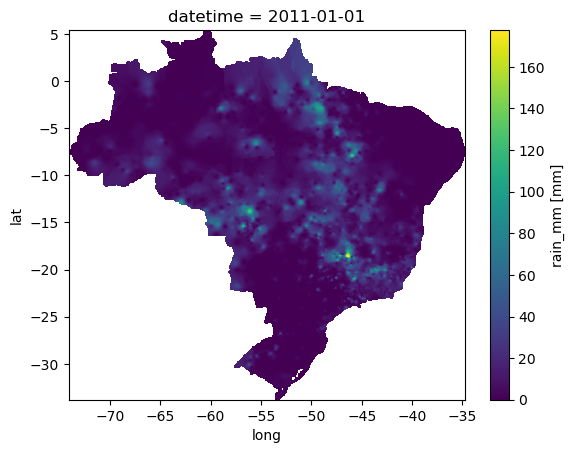

In [7]:
pr.isel(datetime = 0).plot()

### Criando um subset

In [93]:
ds_subset = ds.sel(long = slice(-57, -53), lat = slice(-9, -6))
ds_subset

<xarray.Dataset> Size: 41MB
Dimensions:   (lat: 50, long: 56, datetime: 3653)
Coordinates:
  * lat       (lat) float32 200B -8.95 -8.95 -8.85 -8.75 ... -6.15 -6.05 -6.05
  * long      (long) float32 224B -56.95 -56.95 -56.85 ... -53.15 -53.05 -53.05
  * datetime  (datetime) datetime64[ns] 29kB 2011-01-01 ... 2020-12-31
Data variables:
    rain_mm   (lat, long, datetime) float32 41MB ...

In [ ]:
# ds_subset.to_netcdf(r'.\1 - Organized data gauge\Demo\joao_pessoa.nc')

### Extraindo variáveis

In [94]:
pr = ds_subset['rain_mm']

### Extraindo dados de um ponto

In [109]:
# Convert to DataFrame
df_pr = pr.to_dataframe().reset_index().dropna()
df_pr['long'] = df_pr['long'].astype(float).round(2)
df_pr['lat'] = df_pr['lat'].astype(float).round(2)

df_pr.sort_values(['rain_mm']).tail(60)

,lat,long,datetime,rain_mm
9268821,-6.25,-55.75,2014-03-06,196.608109
8172530,-6.55,-53.15,2013-02-08,196.738754
8377098,-6.55,-53.15,2013-02-08,196.738754
5922282,-7.15,-53.15,2013-02-08,197.676422
6126850,-7.15,-53.15,2013-02-08,197.676422
7763394,-6.65,-53.15,2013-02-08,198.384430
7967962,-6.65,-53.15,2013-02-08,198.384430
9064189,-6.35,-55.75,2014-01-01,200.207260
8859621,-6.35,-55.75,2014-01-01,200.207260
9677893,-6.15,-55.75,2014-01-01,200.865326
